In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", DeprecationWarning)


In [2]:
# LOAD CONFIG FILE FOR EXPERIMENT
# to handle multilple config file, just load one of the latest config file and then duplicate for each env/agent modifying the necessary parameters

# from hydra import compose, initialize
# from omegaconf import OmegaConf

# initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")
# cfg = compose(config_name="config")

In [26]:
# INSTANTIATE ENVIRONMENT
from omegaconf import OmegaConf

global_step = 0
action_repeat = 2
snapshot_ts = global_step * action_repeat
seed = 0

envs_name = {"dmc": ["reacher_easy"]}
runs = {"reacher_easy": {"1": ["38f136942e4a8b219ba3471b9d48117e", "38f136942e4a8b219ba3471b9d48117e"] , "2": ["002d875d9675a3f7bbcb70224069b8d0", "78423885deb37e3ce845c9410e26ce19"] , "3":["202ca7953bcd7528b8be63285053dd0f", "ad021d575129b3d6bbef4af7ffcf8416"] , "5": ["da844415cf783837223393ce1ad50882"]} }
                # "reacher_hard": {"1": [""], "2": , "3": , "5": ,
                # "CustomLift": {"1": , "2": , "3": , "5": }} # env | id number | run number

configs = {"reacher_easy":{}}
envs = {"reacher_easy":{}}

# For each config have a unique environment to avoid issues with different configurations
for k, v in envs_name.items():
    for task in v:
        for id in runs[task]:
            # for run in config_files[task][id]:
            run = runs[task][id][0]
            base_path = f"/mnt/public/projects/mazpie/offline_reacher_benchmark_{id}/offline/{run}/code/exp_local/"
            for subdir, dirs, files in os.walk(base_path):
                    if 'hydra' in subdir:
                        print(subdir)
                        cfg = OmegaConf.load(subdir + "/config.yaml")
                        print(f"{k} - {task}")
                        env = make(k, task, action_repeat=action_repeat, seed=seed, env_config=cfg.env)
                        env.reset()
                        envs[task][id] = env
                        if id == "5":
                            cfg.agent.world_model.objlatent_ratio = 1
                        configs[task][id] = cfg
                            
                        


/mnt/public/projects/mazpie/offline_reacher_benchmark_1/offline/38f136942e4a8b219ba3471b9d48117e/code/exp_local/2024.03.19/111952_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_2/offline/002d875d9675a3f7bbcb70224069b8d0/code/exp_local/2024.03.19/112051_skill_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_2/offline/002d875d9675a3f7bbcb70224069b8d0/code/exp_local/2024.03.19/154134_skill_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_3/offline/202ca7953bcd7528b8be63285053dd0f/code/exp_local/2024.03.19/112620_dreamer_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_5/offline/da844415cf783837223393ce1ad50882/code/exp_local/2024.03.19/112858_skill_focus_reacher_easy_/.hydra
dmc - reacher_easy
/mnt/public/projects/mazpie/offline_reacher_benchmark_5/offline/da844415cf783837223393ce1ad508

In [27]:
# IMPORT AGENT MODEL (WM + Actor Critic) (last snapshot for each model)
from copy import deepcopy 

models = {"reacher_easy": {}}

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def init_agent(cfg):
    from utils import make_dreamer_agent
    return make_dreamer_agent(env.obs_space, env.action_spec(), cfg)

agents = {"reacher_easy": {}}
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for task in runs.keys():
    for id in runs[task].keys():
        agents[task][id] = []
        for run in runs[task][id]:
            agent_path = Path(f"/mnt/public/projects/mazpie/offline_reacher_benchmark_{id}/offline/{run}/code/last_snapshot.pt")
            agent, step = load_agent(agent_path)
            # agent = init_agent(configs[task][id])
            agent.device = device
            agent.wm.device = device
            agent.wm.rssm.device = device
            agent.wm.rssm._cell.device = device
            agent.is_finetune = True
            agent.wm.rssm._full_posterior = True
            agent.cfg.agent.only_expl_during_training = False
            if id == "5":
                agent._shape_skill_latent = 32 * 48
            agents[task][id].append(deepcopy(agent))
        


In [5]:
import collections

def flatten_observation(observation, output_key='observations'):
  if not isinstance(observation, collections.abc.MutableMapping):
    raise ValueError('Can only flatten dict-like observations.')

  if isinstance(observation, collections.OrderedDict):
    keys = observation.keys()
  else:
    # Keep a consistent ordering for other mappings.
    keys = sorted(observation.keys())

  observation_arrays = [observation[key].ravel() for key in keys]
  return type(observation)([(output_key, np.concatenate(observation_arrays))])

def get_target_observation(goal_pose):
    
    eval_env.set_goal_state(goal_pose)    
    obs = eval_env.step(np.array([0,0]))
    return obs

In [28]:
import utils

# Initialization
step = episode = total_reward = total_success = global_step = 0
eval_env = envs["reacher_easy"]["1"]
agent = agents["reacher_easy"]["5"][0]
cfg = configs["reacher_easy"]["5"]

# tensor_target_obs = {
#     k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0).unsqueeze(0)
#     for k, v in target_obs.items()
# }
# embed = agent.wm.encoder(agent.wm.preprocess(tensor_target_obs))
# post, _ = agent.wm.rssm.observe(
#     embed,
#     tensor_target_obs["action"],
#     tensor_target_obs["is_first"],
# )

# f_i = agent.wm.rssm.get_feat(post)
# skill = agent.wm.heads["object_decoder"].object_latent_extractor(f_i)["post"]["mean"][0,0,0,:].unsqueeze(0)


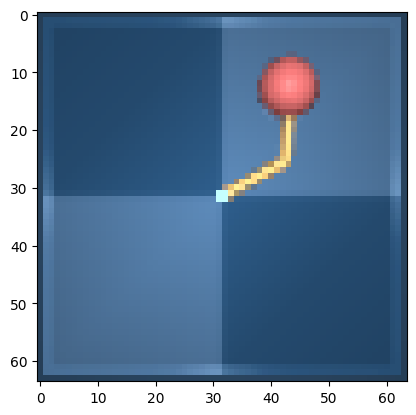

In [44]:
import matplotlib.pyplot as plt
eval_env.visualize_target = True
 
step_to_success = horizon = eval_env.horizon
step_to_success_list = []        
episodes = 2
eval_until_episode = utils.Until(episodes)
meta = agent.init_meta()
obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
video = np.empty([1, int(step_to_success/2) + 1 , 3, *cfg.env.renderer.size])
episode = 0
target_skill_input = ["pos", "obs"]

while eval_until_episode(episode):
    episode_data = []
    
    eval_env.reset()
    # pick random goal for evaluation
    target = env.get_random_goal()
    
    # set target before reset of env
    eval_env.set_target(target[1])                    
    agent.set_target(target[1]) 
    target_obs = get_target_observation(target[0])  
    
    plt.imshow(target_obs["rgb"].transpose(1,2,0))
    
    tensor_target_obs = {
        k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
        for k, v in target_obs.items()
    }
    embed = agent.wm.encoder(agent.wm.preprocess(tensor_target_obs))
    
    warmup_cycles = 2
    latent = agent.wm.rssm.initial(len([target_obs["reward"]]))
    
    for i in range(warmup_cycles):
        latent, _ = agent.wm.rssm.obs_step(
            latent,
            tensor_target_obs["action"],
            embed,
            tensor_target_obs["is_first"],
            should_sample=True
            )
        
    f_i = agent.wm.rssm.get_feat(latent).unsqueeze(0)
    target_skill = agent.wm.heads["object_decoder"].object_latent_extractor(f_i.detach())["post"]["mean"][0,0,0,:].unsqueeze(0)
    
    # target_skill = agent.wm.object_encoder(torch.tensor([[[target]]], device="cuda", dtype=torch.float))["prior"]["mean"][0][0]
    
    obs = eval_env.reset()

    eval_env.set_target(target[1])                    

    # double for visualization purposes
    obs["eval_rgb"] = obs["rgb"]
    
    episode_data.append(obs)
    agent_state = None
    
    while not bool(obs["is_last"]):
        with torch.no_grad(), utils.eval_mode(agent):
            action, agent_state = agent.act(
                obs,
                meta,
                global_step,
                eval_mode=True,
                state=agent_state,
                target_skill=target_skill
            )
        obs = eval_env.step(action)
        
        # in case of dmc manipulator environment, the target position needs to update at every step, given the internal machanics
        if cfg.agent.train_target_reach:
            obs["eval_rgb"] = eval_env.get_rgb_with_target(target)
        else:
            obs["eval_rgb"] = obs["rgb"]

        episode_data.append(obs)
        total_reward += obs["reward"]
        step += 1
        
        # Hacky way to say that step_to_success was set
        if step_to_success == horizon and obs["success"]:
            step_to_success = (step * cfg.action_repeat) - (episode * horizon)

        obj_pos = np.concatenate((obj_pos, [obs["objects_pos"][0]]))

    # log moving average, move to target metrics
    if cfg.agent.train_target_reach:
        target_pos = agent._target_pos.cpu().numpy()
        if episode == 0:
            episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
            move_to_target_metrics = {k: v / cfg.num_eval_episodes for k, v in episode_metrics.items()}
        else:
            episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
            move_to_target_metrics = {k: v / cfg.num_eval_episodes + move_to_target_metrics[k] for k, v in episode_metrics.items()}

    # video output for visualization                 
    if episode==0:
        video = np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)    
    else:
        video = np.concatenate([video, np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)], axis=-1)    
    
    episode += 1
    step_to_success_list += [step_to_success]
    step_to_success = horizon
    total_success += obs["success"]
    obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
    
# logging 
    # log("episode_reward", total_reward / episode)
    # log("avg_success", total_success / episode)
    # log("episode_length", step * self.cfg.action_repeat / episode)
    # log("avg_step_to_success", sum(step_to_success_list) / episode)
    # log("episode", self.global_episode)
    # log("step", self.global_step)b
    # if self.cfg.agent.train_target_reach:
    #         utils.log_metrics_dict(move_to_target_metrics, log)

# if self.global_frame % 25000 == 0: # in order to reduce space loggin space in wandb (takes 5MB each video/TSNE)
    # B, T, C, H, W = video.shape
# video = np.uint8(video * 255)

    # Eval episodes for testing the prior
    # utils.TSNE_analysis(self)         

In [45]:
import imageio
from IPython.display import Video

imageio.mimwrite('test2.mp4', video[0].transpose(0,2,3,1), fps=15) 
Video("/mnt/home/focus/test2.mp4")


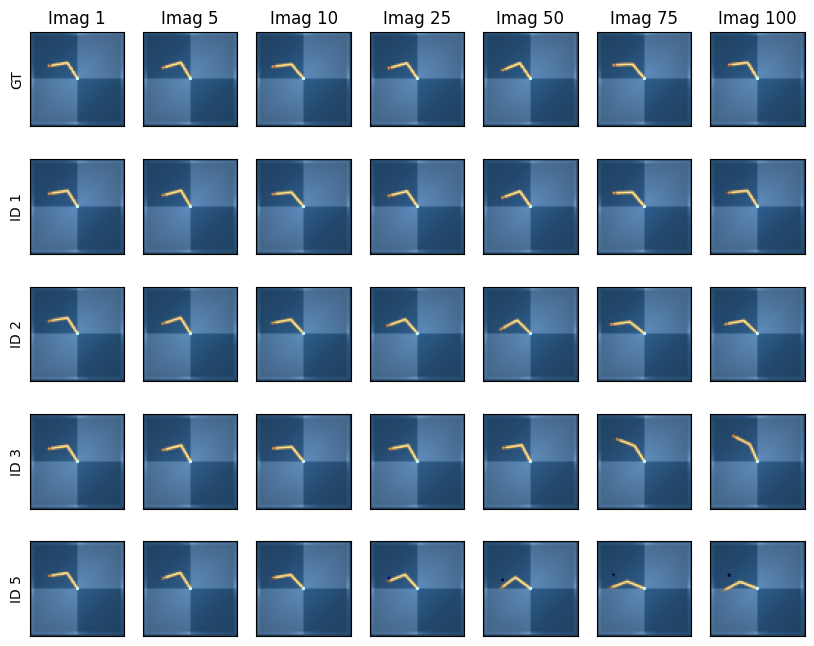

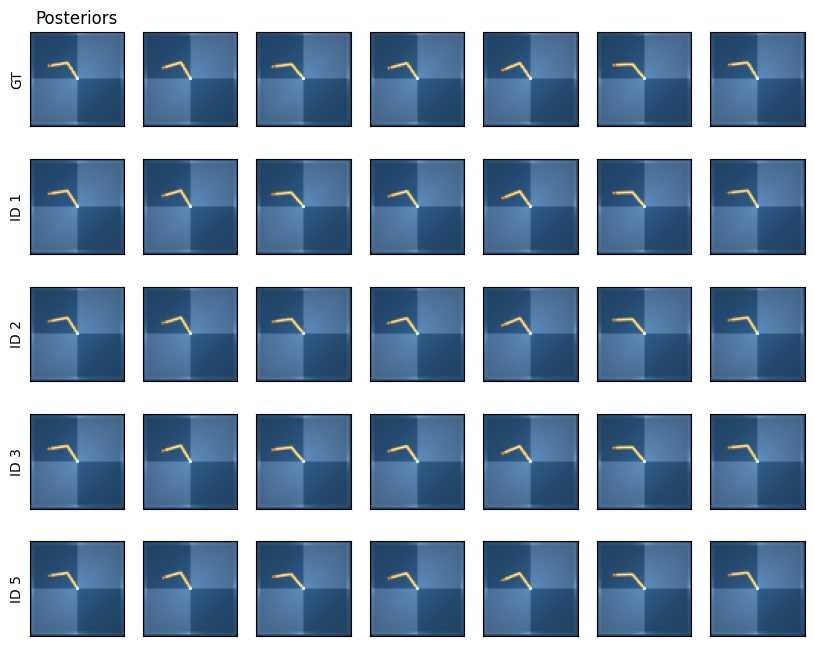

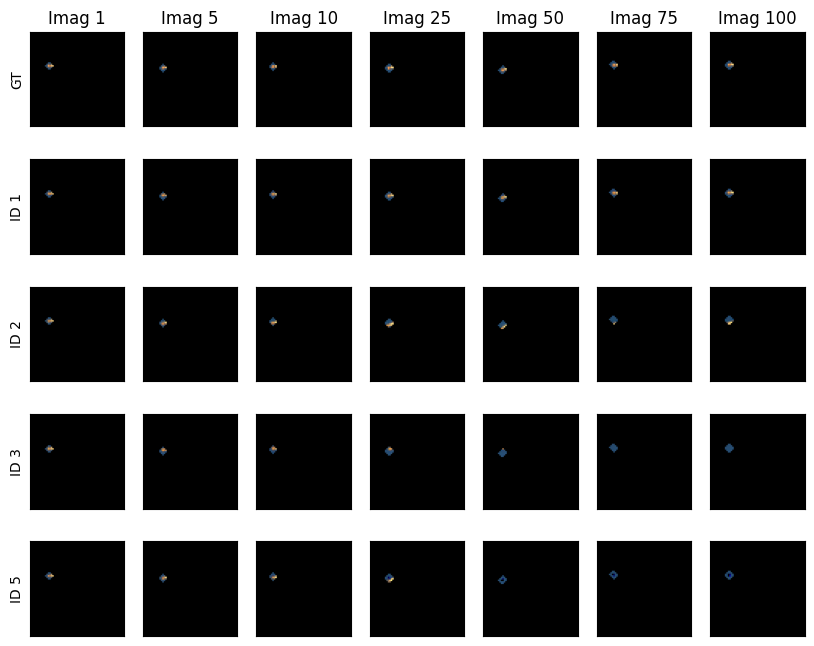

In [55]:
fig1, axs1 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig2, axs2 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig3, axs3 = plt.subplots(5, len(error_steps), figsize=(10, 8))


axs1[0, 0].set_ylabel(f"GT")
axs2[0, 0].set_ylabel(f"GT")
axs3[0, 0].set_ylabel(f"GT")


for i, id in enumerate(runs[task].keys()):
    axs1[i+1, 0].set_ylabel(f"ID {id}")
    axs2[i+1, 0].set_ylabel(f"ID {id}")
    axs3[i+1, 0].set_ylabel(f"ID {id}")
    

for i, s in enumerate(error_steps):
    axs1[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs1[0, i].set_title(f"Imag {s}")
    axs1[0, i].set_xticks([])
    axs1[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs1[y+1, i].imshow(det(prior_recons[task][id][0, s-1].permute(1,2,0)))
        axs1[y+1, i].set_xticks([])
        axs1[y+1, i].set_yticks([])

        
    axs2[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs2[0, 0].set_title(f"Posteriors")
    axs2[0, i].set_xticks([])
    axs2[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs2[y+1, i].imshow(det(post_recons[task][id][0, imag_start_step + s].permute(1,2,0)))
        axs2[y+1, i].set_xticks([])
        axs2[y+1, i].set_yticks([])

    axs3[0, i].imshow((truth_masked[0, imag_start_step + s].transpose(1,2,0)))
    axs3[0, i].set_xticks([])
    axs3[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs3[y+1, i].imshow(prior_recons_masked[task][id][0, s-1].transpose(1,2,0))
        axs3[0, i].set_title(f"Imag {s}")
        axs3[y+1, i].set_xticks([])
        axs3[y+1, i].set_yticks([])


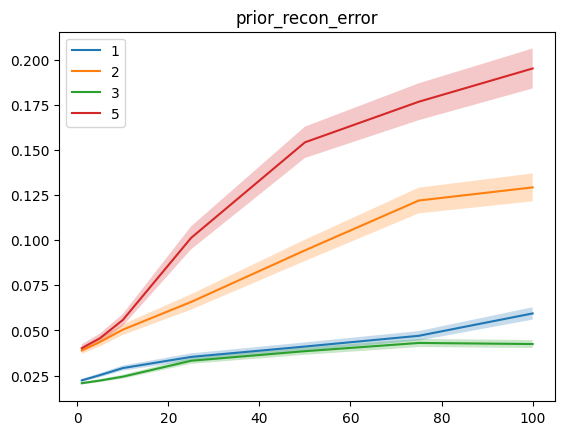

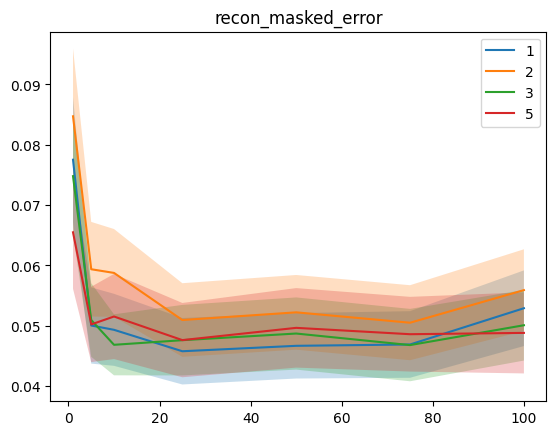

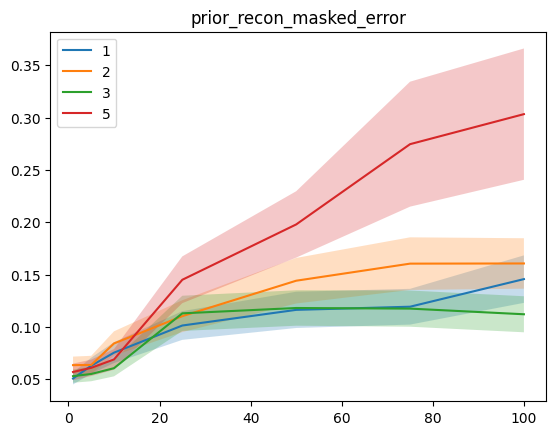

In [56]:
# for each img steps get a single mean value (with all the episodes)

# means = {}
# stds = {}

# for k, v in metrics.items():
#     means[k] = []
#     stds[k] = []
#     for i in range(len(v)):
#         means[k].append(np.array([x["mean"] for x in v[i]]).mean())
#         stds[k].append(np.array([x["std"] for x in v[i]]).mean())
        
plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_error"]]    

    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_error")
    
# plt.plot(error_steps, means["prior_recon_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_error"], stds["prior_recon_error"]), np.add(means["prior_recon_error"], stds["prior_recon_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["recon_masked_error"]]
    # print(means)
    # print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["recon_masked_error"], stds["recon_masked_error"]), np.add(means["recon_masked_error"], stds["recon_masked_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_masked_error"]]
    # print(means)
    # print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["prior_recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), np.add(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), alpha=0.8)
        